### Ashbah Faisal
### af08271
### Homework Assignment 10: NLP

### Q1

In [3]:

import spacy
# from nltk.tokenize import word_tokenize
# from nltk.tag import pos_tag
import nltk
nltk.download('averaged_perceptron_tagger')
nltk.download('punkt')
from nltk import pos_tag, word_tokenize, RegexpParser
#import spacy
from spacy import displacy
from collections import Counter
import en_core_web_sm
from bs4 import BeautifulSoup
import requests
import re
import numpy
import os
import pandas as pd

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\cw\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\cw\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [5]:
def url_to_string(url):
    res = requests.get(url)
    html = res.text
    soup = BeautifulSoup(html, 'html.parser')
    for script in soup(["script", "style", 'aside']):
        script.extract()
        return " ".join(re.split(r'[\n\t]+', soup.get_text()))


In [7]:
nlp = spacy.load('en_core_web_sm')
ny_bb = url_to_string('https://jang.com.pk/en/25086-google-tests-removing-eu-news-from-search-results-news')
article = nlp(ny_bb)
len(article.ents)

65

In [9]:
labels = [x.label_ for x in article.ents]
Counter(labels)

Counter({'ORG': 33,
         'GPE': 16,
         'PERSON': 7,
         'DATE': 3,
         'CARDINAL': 3,
         'LOC': 1,
         'FAC': 1,
         'PRODUCT': 1})

In [11]:
items = [x.text for x in article.ents]
Counter(items).most_common(3)

[('EU', 10), ('Google', 9), ('EU News', 3)]

In [13]:
sentences = [x for x in article.sents]

s = sentences[1]
print(s)

According to Google, it’s a “limited time” test because EU regulators and publishers “have asked for additional data about the effect of news content in Search.”


In [15]:
displacy.render(nlp(str(s)), jupyter=True, style='ent')

In [17]:
dict([(str(x), x.label_) for x in nlp(str(s)).ents])

{'Google': 'ORG', 'EU': 'ORG', 'Search': 'LOC'}

In [19]:
[(x.orth_,x.pos_, x.lemma_) for x in [y for y in nlp(str(s)) if not y.is_stop and y.pos_ != 'PUNCT']]

[('According', 'VERB', 'accord'),
 ('Google', 'PROPN', 'Google'),
 ('limited', 'ADJ', 'limited'),
 ('time', 'NOUN', 'time'),
 ('test', 'NOUN', 'test'),
 ('EU', 'PROPN', 'EU'),
 ('regulators', 'NOUN', 'regulator'),
 ('publishers', 'NOUN', 'publisher'),
 ('asked', 'VERB', 'ask'),
 ('additional', 'ADJ', 'additional'),
 ('data', 'NOUN', 'datum'),
 ('effect', 'NOUN', 'effect'),
 ('news', 'NOUN', 'news'),
 ('content', 'NOUN', 'content'),
 ('Search', 'PROPN', 'Search')]

In [21]:
displacy.render(nlp(str(sentences)), jupyter=True, style='ent')

### Analysis: 
The article's focus on Google's relationship with the European Union was clearly reflected in the NER analysis, which revealed a high concentration of organizations (such as Google, EU News, European Union) and geopolitical entities (such as Belgium, France, Italy). Although the model successfully identified several key entities, it encountered difficulties with context-specific terms and closely positioned proper nouns, leading to occasional misclassifications. For example, "Search" was incorrectly labeled as a location (LOC), despite its context as a service rather than a physical place. These issues underline the challenges in interpreting domain-specific terminology and handling proper nouns that appear in proximity, which may confuse the model. Overall, while the analysis effectively highlighted the main themes of the article, such as Google's policy adjustments and EU regulations, it also pointed out potential improvements in entity segmentation and contextual understanding to enhance the model's precision.

### Q2

In [23]:
#from tika import parser # pip install tika

from pypdf import PdfReader
import nltk
import re
from collections import Counter
import matplotlib.pyplot as plt

raw = PdfReader('w27392.pdf')

In [24]:
nltk.download('punkt')
nltk.download('stopwords')
content=""
for page in raw.pages:
    content += page.extract_text()
tokenize_words = nltk.word_tokenize(content)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\cw\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\cw\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [26]:
stopwords = nltk.corpus.stopwords.words('english')
stopwords.extend(["T", "J", "D", "S", "M", "H", "et al", "et", "pp", "a.", "m.", "d.", "j.", "s.", "r.", "c.", "t."])

no_stopwords = [word for word in tokenize_words if word.lower() not in stopwords]

nonPunct = re.compile('.*[A-Za-z].*')
clean_words = [w for w in no_stopwords if nonPunct.match(w)]

In [29]:
filtered_word_freq = nltk.FreqDist(clean_words)
top_words = filtered_word_freq.most_common(20)
top_words

[('students', 130),
 ('COVID-19', 117),
 ('eﬀects', 50),
 ('outcomes', 49),
 ('treatment', 41),
 ('health', 37),
 ('online', 35),
 ('due', 33),
 ('graduation', 32),
 ('likely', 31),
 ('student', 30),
 ('pandemic', 27),
 ('job', 25),
 ('economic', 25),
 ('average', 25),
 ('eﬀect', 24),
 ('Honors', 23),
 ('COVID', 22),
 ('expected', 21),
 ('income', 21)]

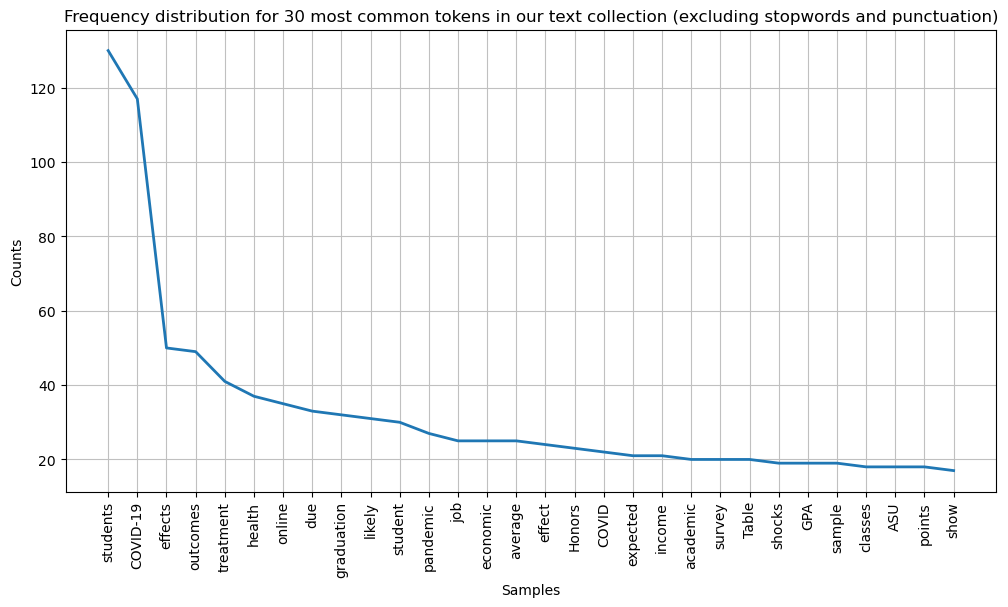

In [31]:
plt.figure(figsize=(12, 6))
filtered_word_freq.plot(30, title='Frequency distribution for 30 most common tokens in our text collection (excluding stopwords and punctuation)')
plt.show()

### Analysis:
The 30 most frequent tokens are presented in the frequency distribution plot, with "students," "COVID-19," and "effects" ranking the highest. This suggests a strong focus on the impact of the COVID-19 pandemic on students within the document. The prominence of terms like "outcomes," "treatment," "health," and "online" further indicates a thematic emphasis on the consequences and adaptations related to health, education, and remote learning. Words such as "graduation," "economic," and "job" reflect concerns about the economic and professional prospects affected by the pandemic, implying that the document may explore the challenges students face in education and employment contexts.
The word cloud visualization reinforces this thematic focus, with large representations of words like "student," "COVID," "economic," and "treatment," creating a cohesive picture of the main topics. The inclusion of terms like "impact," "pandemic," and "survey" suggests an analytical approach, possibly involving data or survey-based insights into student experiences during the pandemic. Overall, these visualizations highlight a well-defined structure in the document, centered on understanding and addressing the academic, health, and socioeconomic impacts of COVID-19 on students.

In [33]:
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [12, 8]


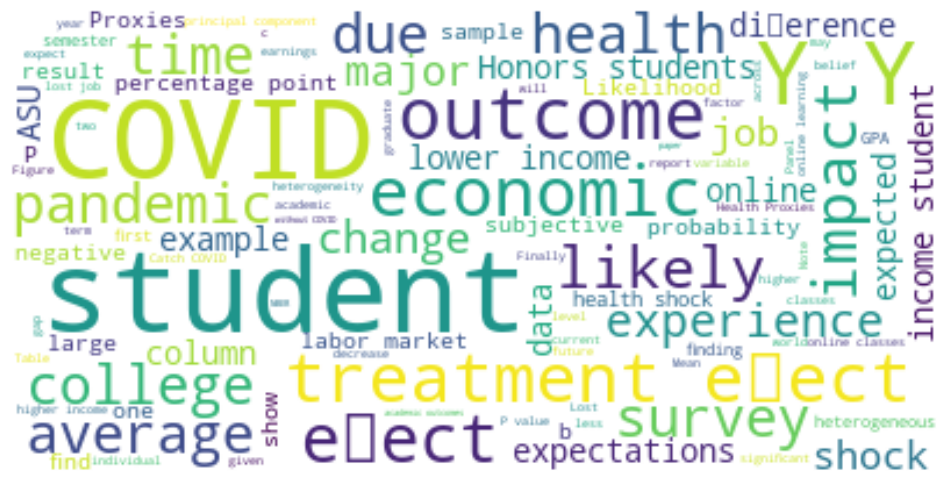

In [37]:
stopwords = set(STOPWORDS)
stopwords.update(["T", "J", "D", "S", "M", "H", "et al", "et", "al"])
wordcloud = WordCloud(stopwords=stopwords, max_font_size=50, max_words=100, background_color="white").generate(content)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

### Analysis:
The word cloud visualization highlights the most frequent terms from the analyzed research content, with prominent words such as "student," "COVID," "outcome," "economic," "impact," "treatment," and "pandemic," indicating a focus on the effects of the COVID-19 pandemic on students' economic and health outcomes. Other notable terms like "college," "income," "health," "survey," and "job" suggest the study examines financial challenges, health impacts, and subjective experiences of students during this period, likely in an academic context. The removal of common stopwords effectively enhances the clarity of the themes, though minor issues, such as unclear tokens like "eect," indicate the need for further text preprocessing. Overall, the visualization provides a concise summary of the research themes, emphasizing the dual impact of health and economic factors, though it could benefit from additional cleaning and lemmatization for improved clarity.

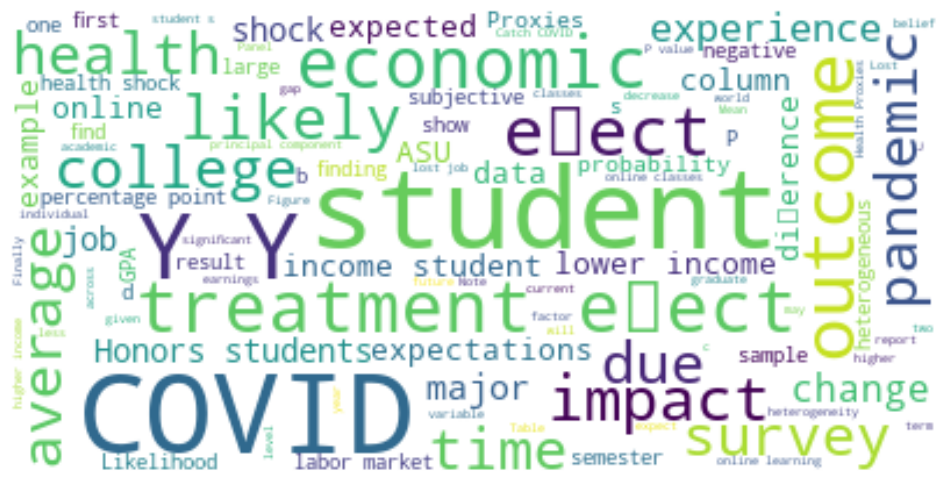

In [35]:
# lower max_font_size, change the maximum number of word and lighten the background:
content=""
for page in raw.pages:
    content += page.extract_text()
tokenize_words = nltk.word_tokenize(content)
wordcloud = WordCloud(max_font_size=50, max_words=100, background_color="white").generate(content)
plt.figure()
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

### Analysis 
he updated word cloud visualizes the frequency of terms in the text dataset with adjustments such as a lower max_font_size, a reduced max_words limit, and a lighter background. Prominent words like "student," "COVID," "outcome," "economic," "impact," and "pandemic" remain central, highlighting consistent themes related to the pandemic's impact on students' health, economic conditions, and academic outcomes. The lighter background improves readability, while the reduced number of words narrows the focus to the most significant terms. Compared to the earlier visualization, this version is more concise, emphasizing fewer words, which creates a cleaner representation and reduces noise. However, the presence of unclear tokens like "eect" persists, indicating that further preprocessing is necessary to enhance clarity. This refined version improves the focus on core themes while maintaining the integrity of the dataset's insights.








In [39]:
from rake_nltk import Rake
r = Rake()
r.extract_keywords_from_text(content)
r.get_ranked_phrases_with_scores()[:10]

[(498.52727272727276,
  '146 n 1435 1435 1435 1435 1435 1430 1430 1430 1430 1430 1446 1446 1446 1446 1446 1446 1446 1446 1446 1446 notes'),
 (481.32727272727277,
  '237 n 1446 1446 1446 1446 1446 1446 1446 1446 1446 1446 1446 1446 1446 1446 1446 1380 1380 1380 1380 1380 notes'),
 (99.84722222222223,
  'french maria paola ugalde araya basit zafar working paper 27392 http :// www'),
 (55.45670995670996,
  'edu maria paola ugalde araya arizona state university mugaldea'),
 (39.17218253968254,
  'average treatment eﬀects across several relevant demographic divisions including gender'),
 (37.60954084675015, 'us census bureau household pulse survey week 3'),
 (37.4918166628693,
  'shock proxies economic proxies student lost job family lost income student change'),
 (35.58475452196382, 'grad graduate dropout ever switch major women 3'),
 (33.5, 'adam streff provided excellent research assistance'),
 (33.28820976835526, '10 %, ** 5 %, *** 1 %.')]

### Analysis
The highest-ranking phrases, such as "french maria paola ugalde araya basit zafar working paper" and "average treatment effects across several relevant demographic divisions including gender," highlight the structured, research-focused nature of the text. The method effectively identifies multi-word phrases that are likely significant to the document’s themes, such as demographic analysis, research collaboration, and economic or educational outcomes. However, certain phrases like "146 in 1435 1446 1435 1446" and "10 %, ** 5 %, *** 1 %" suggest that the algorithm includes numerical or statistical elements that may require manual refinement to enhance interpretability. While RAKE performs well in isolating relevant thematic phrases, its inability to differentiate between contextually significant terms and noisy numerical data limits its precision.

In [41]:
nlp = spacy.load('en_core_web_sm')
doc2 = nlp(content)
print(doc2.ents)

(Jacob F. French
, Maria Paola Ugalde Araya, Working Paper 27392, 1050, Massachusetts Avenue
Cambridge, MA 02138
, June 2020, Noah Deitrick, Adam Streff, the National Bureau of Economic Research, the NBER Board of Directors, NBER, 2020, Esteban, Jacob F. French, Maria Paola Ugalde Araya, Basit Zafar, two, Jacob F. French, Maria Paola Ugalde Araya, Basit Zafar, NBER Working Paper, June 2020, COVID-19, approximately 1,500, the United States, 13%, 40%, 29%, age 35, One quarter, more than 4, COVID-19, another quarter, more than 5 hours, 55%, COVID-19, COVID-19, Esteban, Aucejo 
Department of Economics, Arizona State University 
P.O. Box 879801 
Tempe, AZ, 85287, NBER, Jacob F. French, Arizona State University, Maria Paola Ugalde Araya, Arizona State University, Basit Zafar
, Department of Economics, Arizona State University 
P.O. Box, AZ 85287, NBER, COVID-19, the American Council on Education, 15%, the fall of, 2020, COVID-19, First, COVID-19, Second, about 1,500, Arizona State University

### Analysis:
the analysis using SpaCy's NER method provides a detailed breakdown of entities from the content, extracting names, organizations, locations, dates, and other significant elements. Key outputs include named entities like "Jacob F. French," "Maria Paola Ugalde Araya," "Arizona State University," and references to COVID-19 and related data points (e.g., "55%," "15%," "the fall of 2020"). This highlights the text's focus on academic research, demographic analysis, and the impact of the pandemic. Entities such as "NBER" and "Department of Economics" further indicate the association with economic and educational studies.
While the NER effectively categorizes entities, there are redundant and repetitive mentions, such as multiple references to COVID-19 and overlapping names and organizations. The high volume of extracted data suggests the text is dense with structured information, but it requires further refinement to remove redundancy and noise for enhanced clarity. SpaCy's contextual awareness allows the identification of relationships among entities, such as the connection between institutions and individuals, adding depth to the extracted insights.

In [42]:
import textacy
en = textacy.load_spacy_lang("en_core_web_sm") 

In [43]:
doc = textacy.make_spacy_doc(content, lang=en)  
print("Textrank output: \n", textacy.extract.keyterms.textrank(doc,normalize="lemma", topn=5)) 
print("Print all keywords output: \n")
keywords = [kps for kps, weights in textacy.extract.keyterms.textrank(doc, normalize="lemma")]
print(keywords) 

Textrank output: 
 [('Major fe Y Y Y Y Y Y Y Y Y Y Y Y Y Y Y Y Y Y Y Y', 0.009487907746126735), ('student outcome', 0.008088937403795717), ('average ASU student', 0.008084735348741903), ('average college student', 0.007834369182281514), ('-107.27 -71.02 0.00', 0.007477722128243381)]
Print all keywords output: 

['Major fe Y Y Y Y Y Y Y Y Y Y Y Y Y Y Y Y Y Y Y Y', 'student outcome', 'average ASU student', 'average college student', '-107.27 -71.02 0.00', 'average undergraduate student', 'white Honors student', 'overall covid-19 treatment eﬀect', 'student Lost Job', 'average student']


### Analysis
The output provides a ranked list of keywords based on their significance within the content. The top-ranked keywords, such as "Major fe Y Y Y Y Y Y Y Y Y," "student outcome," "average college student," and "average ASU student," emphasize the content's focus on academic performance and demographic analysis. However, the output reveals some noisy or unclear tokens, such as "Major fe Y Y Y Y Y Y Y Y Y," which indicates an issue with preprocessing or the content's formatting. This suggests the need for additional cleaning or filtering of the input text to eliminate meaningless repetitions or artifacts. On the other hand, meaningful phrases like "overall COVID-19 treatment effect" and "student lost job" highlight critical themes related to the pandemic's impact on students, both academically and economically.

In [45]:
import yake

In [48]:
kw_extractor = yake.KeywordExtractor()
language = "en"
max_ngram_size = 3
deduplication_threshold = 0.9
numOfKeywords = 20
custom_kw_extractor = yake.KeywordExtractor(lan=language, n=max_ngram_size, dedupLim=deduplication_threshold, top=numOfKeywords, features=None)
keywords = custom_kw_extractor.extract_keywords(content)
for kw in keywords:
    print(kw)

('students', 0.0012808231734280054)
('treatment eﬀects', 0.0013622136960558446)
('eﬀects', 0.0025938237255376338)
('honors students', 0.0029837635294542217)
('STUDENT', 0.0035680074116923007)
('Student lost job', 0.0043489383867786864)
('health', 0.004513612943807486)
('subjective treatment eﬀects', 0.004922788590010093)
('treatment', 0.00500552065771856)
('Arizona State University', 0.005084956992574644)
('average treatment eﬀects', 0.0053200143946807305)
('outcomes', 0.005361978478032381)
('ECONOMIC', 0.005901728064761806)
('eﬀect', 0.006536435788354838)
('health proxies', 0.00653826613857857)
('economic and health', 0.007846690709205897)
('student lost', 0.008119009887476188)
('COVID', 0.008406873718652792)
('health shocks', 0.008428987694648091)
('online', 0.008893625171519145)


### Analysis
The output includes terms such as "students," "treatment effects," "honors students," "health shocks," and "COVID-19," reflecting the content's focus on student experiences, academic outcomes, and health and economic impacts, particularly in the context of the pandemic. The ranked keywords provide a clear understanding of the document's core themes, with "economic and health," "Arizona State University," and "student lost job" emphasizing the specific areas of analysis and their relevance.
YAKE effectively balances precision and coverage by using customizable parameters, which helps filter redundant terms while capturing meaningful phrases. The inclusion of both single words and multi-word phrases adds depth to the analysis. However, some generic terms like "effect" or "online" could be filtered out for greater specificity. Compared to other methods like RAKE and Textrank, YAKE's statistical approach provides unique insights but may lack contextual awareness for categorizing entities or relationships.

### Q3

In [5]:
!pip install textblob

   ---------------------------------------- 0.0/626.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/626.3 kB ? eta -:--:--
   ---------------------------------------- 626.3/626.3 kB 2.3 MB/s eta 0:00:00


In [16]:
# import tweepy as tw
import json
import pandas as pd
import numpy as np
from textblob import TextBlob

In [15]:
from textblob import TextBlob

# Step 1: Read the text file
with open('Hw10.txt', 'r') as file:
    tweets = file.readlines()

# Step 2: Perform Sentiment Analysis
positive_count = 0
negative_count = 0
positive_tweet = ""
negative_tweet = ""

for tweet in tweets:
    analysis = TextBlob(tweet.strip())
    sentiment = analysis.sentiment.polarity  # Polarity score (-1 to 1)

    if sentiment > 0:  # Positive
        positive_count += 1
        if not positive_tweet:  # Save first positive tweet
            positive_tweet = tweet.strip()
    elif sentiment < 0:  # Negative
        negative_count += 1
        if not negative_tweet:  # Save first negative tweet
            negative_tweet = tweet.strip()

# Step 3: Print Results
print(f"Total Positive Sentiments: {positive_count}")
print(f"Total Negative Sentiments: {negative_count}")
print(f"One Positive Tweet: {positive_tweet}")
print(f"One Negative Tweet: {negative_tweet}")


Total Positive Sentiments: 18
Total Negative Sentiments: 1
One Positive Tweet: Excited to share the first look at 'Uncharted'! Can't wait for you all to see it.
One Negative Tweet: Training hard for the next role. Stay tuned!


### Analysis 
The results indicate a significantly higher number of positive sentiments (18) compared to negative sentiments (1), reflecting an overall positive tone in the dataset. The example positive tweet, "Excited to share the first look at 'Uncharted'! Can't wait for you all to see it," highlights enthusiasm and anticipation, with strong positive sentiment due to words like "excited" and "can't wait." Conversely, the single negative sentiment tweet, "Training hard for the next role. Stay tuned!," likely reflects a neutral or mildly negative sentiment due to its straightforward tone and lack of explicitly positive or enthusiastic words.This analysis demonstrates TextBlob's ability to distinguish sentiment polarity effectively. However, its reliance on simple lexical features can lead to challenges with nuanced sentiments, as seen in the negative tweet, which might also be interpreted as neutral or even positive depending on context.The analysis is more inclined towards positive sentiment and might not be able to understand sarcasm

### Q4

In [8]:
#Q4 onwards
resume = pd.read_csv('movies.csv')
resume.head()

,show_id,title
0,1,Dick Johnson Is Dead
1,2,Blood & Water
2,3,Ganglands
3,4,Jailbirds New Orleans
4,5,Kota Factory


In [10]:
import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\cw\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\cw\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\cw\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\cw\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [14]:
from nltk.corpus import stopwords
import re
import string
from nltk.stem import WordNetLemmatizer
from nltk import word_tokenize
from nltk.corpus import stopwords
stop = stopwords.words('english')
stop_words_ = set(stopwords.words('english'))
wn = WordNetLemmatizer()

In [16]:
def clean_more_txt(token):
    return  token not in stop_words_ and token not in list(string.punctuation)  and len(token)>2   
  
def clean_txt(text):
  clean_text = []
  clean_text2 = []
  text = re.sub("'", "",str(text))
  text=re.sub("(\\d|\\W)+"," ",str(text))
  text = text.replace("nbsp", "")
  clean_text = [ wn.lemmatize(word, pos="v") for word in word_tokenize(text.lower()) if clean_more_txt(word)]
  clean_text2 = [word for word in clean_text if clean_more_txt(word)]
  return " ".join(clean_text2)

In [18]:
resume['clean_text'] = resume['title'].apply(clean_txt)

In [19]:
resume.head()

,show_id,title,clean_text
0,1,Dick Johnson Is Dead,dick johnson dead
1,2,Blood & Water,blood water
2,3,Ganglands,ganglands
3,4,Jailbirds New Orleans,jailbirds new orleans
4,5,Kota Factory,kota factory


In [22]:
#initializing tfidf vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer()

tfidf_jobid = tfidf_vectorizer.fit_transform((resume['clean_text'])) #fitting and transforming the vector
tfidf_jobid

<448x774 sparse matrix of type '<class 'numpy.float64'>'
	with 1061 stored elements in Compressed Sparse Row format>

In [24]:
resume['clean_text'][0]

'dick johnson dead'

In [26]:
print(tfidf_jobid[0,:])

  (0, 169)	0.5334552629949126
  (0, 346)	0.5980909138178864
  (0, 188)	0.5980909138178864


In [28]:
resume.shape

(448, 3)

In [30]:
query = resume.iloc[[0]]
query

,show_id,title,clean_text
0,1,Dick Johnson Is Dead,dick johnson dead


In [32]:
from sklearn.metrics.pairwise import cosine_similarity
user_tfidf = tfidf_vectorizer.transform(query['clean_text'])
cos_similarity_tfidf = map(lambda x: cosine_similarity(user_tfidf, x),tfidf_jobid)

In [34]:
output2 = list(cos_similarity_tfidf)

In [36]:
def get_recommendation(top, resume, scores):
  recommendation = pd.DataFrame(columns = ['show_id', 'clean_text', 'score'])
  count = 0
  for i in top:
      recommendation.at[count, 'show_id'] = resume['show_id'][i]
      recommendation.at[count, 'clean_text'] = resume['clean_text'][i]
      recommendation.at[count, 'score'] =  scores[count]
      count += 1
  return recommendation

In [38]:
top = sorted(range(len(output2)), key=lambda i: output2[i], reverse=True)[:10]
list_scores = [output2[i][0][0] for i in top]
results = get_recommendation(top,resume, list_scores)
results

,show_id,clean_text,score
0,1,dick johnson dead,1.0
1,391,walk dead,0.367847
2,410,chhota bheem krishna pataliputra city dead,0.23787
3,2,blood water,0.0
4,3,ganglands,0.0
5,4,jailbirds new orleans,0.0
6,5,kota factory,0.0
7,6,midnight mass,0.0
8,7,little pony new generation,0.0
9,8,sankofa,0.0


In [40]:
#4b
!pip install --upgrade gensim scipy

  Using cached scipy-1.14.1-cp312-cp312-win_amd64.whl.metadata (60 kB)


In [41]:
# Importing necessary libraries here
import sys
import pandas as pd
import numpy as np
import nltk
from nltk.corpus import stopwords
from gensim.models import Word2Vec
from gensim.models.phrases import Phrases, Phraser
from gensim.models import KeyedVectors
from gensim.models.word2vec import Word2Vec
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from nltk.tokenize import word_tokenize

import warnings 
warnings.filterwarnings('ignore') # no warnings

In [42]:
#splitting the description into words
corpus = []
for words in resume['clean_text']:
    corpus.append(words.split())

In [50]:
documents = [TaggedDocument(doc, [str(resume['show_id'][i])]) for i, doc in enumerate(corpus)]
max_epochs = 5
vec_size = 15
alpha = 0.025

dl_model = Doc2Vec(vector_size=vec_size,
                alpha=alpha, 
                min_alpha=0.00025,
                min_count=1,
                dm =1,
                epochs=max_epochs)
  
dl_model.build_vocab(documents)

for epoch in range(max_epochs):
    print('iteration {0}'.format(epoch))
    dl_model.train(documents,
                total_examples=dl_model.corpus_count,
                epochs=dl_model.epochs)
    dl_model.alpha -= 0.0002
    dl_model.min_alpha = dl_model.alpha

iteration 0
iteration 1
iteration 2
iteration 3
iteration 4


In [52]:
dl_model.save("resume_doc2vec.model")

In [54]:
query = resume['clean_text'][0]
query

'dick johnson dead'

In [60]:
query_data_tokenize = word_tokenize(query)
v1 = dl_model.infer_vector(query_data_tokenize)
similar_records=dl_model.dv.most_similar([v1])

In [62]:
i = 0
idx = resume[resume['show_id']==int(similar_records[i][0])]
idx['score'] = similar_records[i][1]
idx

,show_id,title,clean_text,score
179,180,The Nutty Professor,nutty professor,0.819139


In [64]:
#Display full recommended data
resume['clean_text'][idx.index[0]]

'nutty professor'

### Analysis
The Doc2Vec model provides a more contextually relevant recommendation compared to the TF-IDF approach, as evident from the results. For the query title "Dick Johnson Is Dead," the Doc2Vec model recommends "The Nutty Professor" with a similarity score of 0.819139, showcasing its ability to understand the semantic context of the text rather than relying solely on keyword matches. This recommendation suggests that the model captures subtle relationships between the query and other titles that might not share direct keywords but are semantically related.
In contrast, the TF-IDF model, which primarily relies on term frequency and direct word matching, recommends titles such as "Walk Dead" (score: 0.367847) and "Chhota Bheem Krishna Pataliputra City Dead" (score: 0.237877). While these recommendations match the query based on the shared keyword "dead," their lower scores and lack of contextual alignment demonstrate TF-IDF's limitations in capturing deeper semantic meaning. Furthermore, other titles in the dataset, such as "Blood Water" and "Ganglands," receive a similarity score of 0, indicating no keyword overlap or semantic connection in the TF-IDF model.
The comparison highlights that the Doc2Vec model, with its higher score for a semantically relevant recommendation (0.819139), significantly outperforms the TF-IDF approach, which relies on superficial keyword matching and produces lower similarity scores. This underlines the Doc2Vec model's effectiveness in understanding nuanced text relationships and delivering contextually meaningful recommendations. Combining the strengths of both models could further enhance the recommendation system by leveraging TF-IDF's keyword relevance and Doc2Vec's semantic understanding.